In [3]:
import os
os.environ["PATH"] = "/data/apps/extern/spack_on/gcc/9.3.0/texlive/20220321-oikenzl6gekq5lsohdm6jnnuj276s2ba/bin/x86_64-linux:" + os.environ.get("PATH", "")

import sys
from pathlib import Path

this_notebook = Path().resolve()

project_root = this_notebook.parents[0]

if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

## Module imports

In [4]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm, LogNorm, SymLogNorm

plt.rc('text', usetex=True)
plt.rc('font', family='serif', size=12)

#import Zeus
import zeus21

#set up the CLASS cosmology
from classy import Class
import mcfit
from scipy.interpolate import interp1d

## Get high-res $\xi_U$ using memory-friendly method

In [5]:
UserParams = zeus21.User_Parameters(precisionboost=1.2)

# cosmo inputs from table 2 last column of 1807.06209, as 21cmFAST
ombh2 = 0.02242 
omch2 = 0.11933
tau_re = 0.0544
hLittle = 0.6766
ns = 0.9665
As = np.exp(3.047)*10**(-10.)

CosmoParams_input = zeus21.Cosmo_Parameters_Input(
    omegac = omch2, omegab = ombh2, h_fid = hLittle, As = As, ns = ns, tau_fid = tau_re, 
    USE_RELATIVE_VELOCITIES = True, Flag_emulate_21cmfast=False,
    ANISO_XI_ETA = False
    )

ClassCosmoVCB = Class()
ClassCosmoVCB.set({'omega_b': CosmoParams_input.omegab,
                   'omega_cdm': CosmoParams_input.omegac,
                   'h': CosmoParams_input.h_fid,
                   'A_s': CosmoParams_input.As,
                   'n_s': CosmoParams_input.ns,
                   'tau_reio': CosmoParams_input.tau_fid})
ClassCosmoVCB.set({'output':'vTk'})
ClassCosmoVCB.set({'P_k_max_1/Mpc':50.0, 'z_max_pk':12000})
ClassCosmoVCB.set({'gauge':'newtonian'})
ClassCosmoVCB.compute()

# Cosmo_Parameters = zeus21.Cosmo_Parameters(UserParams, CosmoParams_input, ClassyCosmo) 

In [6]:
from scipy.interpolate import interp1d

rlist = np.geomspace(0.1, 3000, 300)
klist, _dummy_ = mcfit.xi2P(rlist, l=0, lowring=True)(0*rlist, extrap=False)

# kmask = (klist >= 1e-3) & (klist <= 1.0)
# klist_trim = klist[kmask]
# Plist_trim = Plist[kmask]

z_drag = ClassCosmoVCB.get_current_derived_parameters(['z_d'])['z_d']
velTransFunc = ClassCosmoVCB.get_transfer(z_drag)

c_kms = 299792.458
k_vcb = velTransFunc['k (h/Mpc)'] * CosmoParams_input.h_fid
theta_b = velTransFunc['t_b']
theta_c = velTransFunc['t_cdm']
interp_func_theta_b = interp1d(k_vcb, theta_b, kind='cubic', fill_value="extrapolate")
interp_func_theta_c = interp1d(k_vcb, theta_c, kind='cubic', fill_value="extrapolate")
theta_b_dense = interp_func_theta_b(klist)
theta_c_dense = interp_func_theta_c(klist)

P_vcb = CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) * (theta_b_dense - theta_c_dense)**2/klist**2 * 2 * np.pi**2 / klist**3
sigma_vcb = np.sqrt(np.trapz(CosmoParams_input.As * (klist/0.05)**(CosmoParams_input.ns-1) / klist * (theta_b_dense - theta_c_dense)**2/klist**2, klist)) * c_kms


def Window(k,R):
        x = k * R
        return 3.0/x**2 * (np.sin(x)/x - np.cos(x))

In [7]:
# Original implementation (causes OOM)
# lengthRarray = len(rlist)
#
# windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
# windowR2 = Window(klist.reshape(1, lengthRarray,1), rlist.reshape(1, 1, lengthRarray))
#
# psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2
# psi_integrand_base = psi_integrand_base[:, :, np.newaxis, :]
#
# psi_prefactor = 1 / (3 * (sigma_vcb/c_kms)**2)
#
# r_transpose = np.transpose([rlist])
# j0bessel = lambda x: np.sin(x)/x
# j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x)/x - 3*np.cos(x)/x**2
#
# psi0 = 1 * psi_prefactor * np.trapz(psi_integrand_base * j0bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                     klist, axis = -1)
# psi2 = -2 * psi_prefactor * np.trapz(psi_integrand_base * j2bessel(klist * r_transpose)[np.newaxis, np.newaxis, :, :],
#                                         klist, axis = -1)
#
# xi_para_RR_CF = psi0 + psi2
# xi_perp_RR_CF = psi0 - 0.5 * psi2
#
# # Normalize them
# xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
# xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

lengthRarray = len(rlist)

windowR1 = Window(klist.reshape(lengthRarray, 1, 1), rlist.reshape(1, 1, lengthRarray))
windowR2 = Window(klist.reshape(1, lengthRarray, 1), rlist.reshape(1, 1, lengthRarray))
psi_integrand_base = klist**2 / 2 / np.pi**2 * P_vcb * windowR1 * windowR2

psi_prefactor = 1 / (3 * (sigma_vcb / c_kms)**2)

r_transpose = np.transpose([rlist])
j0bessel = lambda x: np.sin(x) / x
j2bessel = lambda x: (3 / x**2 - 1) * np.sin(x) / x - 3 * np.cos(x) / x**2

# Trapezoid weights so each integration can be done as a weighted contraction.
dk = np.diff(klist)
trapz_w = np.empty_like(klist)
trapz_w[0] = 0.5 * dk[0]
trapz_w[-1] = 0.5 * dk[-1]
trapz_w[1:-1] = 0.5 * (klist[2:] - klist[:-2])

j0_grid = j0bessel(klist * r_transpose)
j2_grid = j2bessel(klist * r_transpose)

psi0 = np.empty((lengthRarray, lengthRarray, lengthRarray), dtype=np.float64)
psi2 = np.empty_like(psi0)

for ir in range(lengthRarray):
    w0 = j0_grid[ir] * trapz_w
    w2 = j2_grid[ir] * trapz_w
    psi0[:, :, ir] = psi_prefactor * np.tensordot(psi_integrand_base, w0, axes=([-1], [0]))
    psi2[:, :, ir] = -2 * psi_prefactor * np.tensordot(psi_integrand_base, w2, axes=([-1], [0]))

xi_para_RR_CF = psi0 + psi2
xi_perp_RR_CF = psi0 - 0.5 * psi2

# Normalize them
xi_para_RR_CF /= np.max(np.abs(xi_para_RR_CF))
xi_perp_RR_CF /= np.max(np.abs(xi_perp_RR_CF))

In [16]:
# Real run values from xi_U_comparison.ipynb
lambda1 = 1.1819690031628485
lambda2 = 1.1819690031628485

rho_para = xi_para_RR_CF
rho_perp = xi_perp_RR_CF

lambda_term = 4 * lambda1 * lambda2 / (1 + 2 * lambda1) / (1 + 2 * lambda2)
xi_U_highres = ((1 - lambda_term * rho_para**2) * (1 - lambda_term * rho_perp**2) ** 2) ** (-1/2) - 1
xi_U_highres_normalized = xi_U_highres / xi_U_highres.max()

## Retrieve the $\xi_U$'s computed in `xi_U_comparison.ipynb`

In [12]:
from pathlib import Path

candidate_files = [
    Path("output/xi_U_normalized_data.npz"),
    project_root / "aniso_tests" / "output" / "xi_U_normalized_data.npz",
]

for data_file in candidate_files:
    if data_file.exists():
        break
else:
    raise FileNotFoundError(
        "Could not find xi_U_normalized_data.npz in ./output or project_root/aniso_tests/output"
    )

saved = np.load(data_file)
r_saved = saved["rlist"]
xi_U_zeus_saved = saved["xi_U_zeus_normalized"]
xi_U_aniso_saved = saved["xi_U_aniso_normalized"]
xi_U_corrected_saved = saved["xi_U_corrected_normalized"]

print(f"Loaded saved xi_U data from {data_file.resolve()}")

Loaded saved xi_U data from /home/yzhan629/Zeus21/aniso_tests/output/xi_U_normalized_data.npz


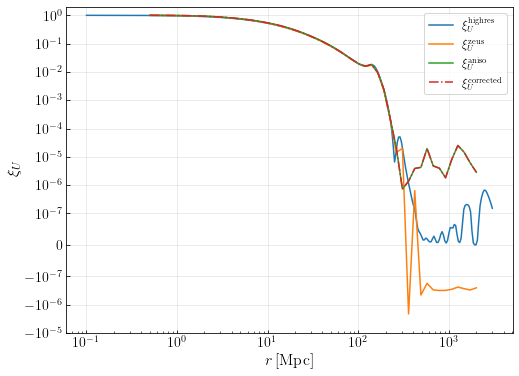

In [19]:
fig, ax = plt.subplots(figsize=(8, 6))
ax.plot(rlist, xi_U_highres_normalized[0, 0, :], label=r'$\xi_U^{\mathrm{highres}}$')
ax.plot(r_saved, xi_U_zeus_saved, label=r"$\xi_U^{\mathrm{zeus}}$")
ax.plot(r_saved, xi_U_aniso_saved, label=r"$\xi_U^{\mathrm{aniso}}$")
ax.plot(r_saved, xi_U_corrected_saved, linestyle="-.", label=r"$\xi_U^{\mathrm{corrected}}$")
ax.set_ylim(-1e-5, 2)
ax.set_xscale("log")
ax.set_yscale('symlog', linthresh=1e-7)
ax.set_xlabel(r"$r\,[\mathrm{Mpc}]$", fontsize=16)
ax.set_ylabel(r"$\xi_U$", fontsize=16)
ax.legend()
ax.tick_params(axis="both", which="both", direction="in", labelsize=14)
ax.grid(True, alpha=0.3)